In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Memuat file biner hasil olahan preprocessing.ipynb
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("=== DATASET BERHASIL DI-LOAD ===")
print(f"Data Training Fitur Shape : {X_train.shape}")
print(f"Data Testing Fitur Shape  : {X_test.shape}")

=== DATASET BERHASIL DI-LOAD ===
Data Training Fitur Shape : (1238, 20, 64)
Data Testing Fitur Shape  : (310, 20, 64)


In [5]:
# Inisialisasi parameter dimensi input tensor
TIME_STEPS = X_train.shape[1]
INPUT_DIM = X_train.shape[2]

# Konstruksi model sekuensial LSTM biner
model = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, INPUT_DIM), return_sequences=True),
    Dropout(0.2),
    
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')  # Klasifikasi biner (Kosong vs Terisi)
])

# Kompilasi spesifikasi model matematis
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Menjalankan proses pelatihan model neural network
print("\n=== MEMULAI PROSES TRAINING MODEL LSTM ===")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,562 (181.88 KB)

 Trainable params: 46,562 (181.88 KB)

 Non-trainable params: 0 (0.00 B)


=== MEMULAI PROSES TRAINING MODEL LSTM ===
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6276 - loss: 0.6282 - val_accuracy: 0.8742 - val_loss: 0.4414
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8336 - loss: 0.4589 - val_accuracy: 0.5161 - val_loss: 1.0646
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5759 - loss: 0.6670 - val_accuracy: 0.9355 - val_loss: 0.3350
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6155 - loss: 0.6246 - val_accuracy: 0.5871 - val_loss: 0.6729
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6414 - loss: 0.6405 - val_accuracy: 0.7065 - val_loss: 0.5649
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7036 - loss: 0.5598 - val_accuracy: 0.6806 - val_loss: 0.5388
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8675 - loss: 0.3606 - val_accuracy: 0.9290 - val_loss: 0.2470
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9354 - lo

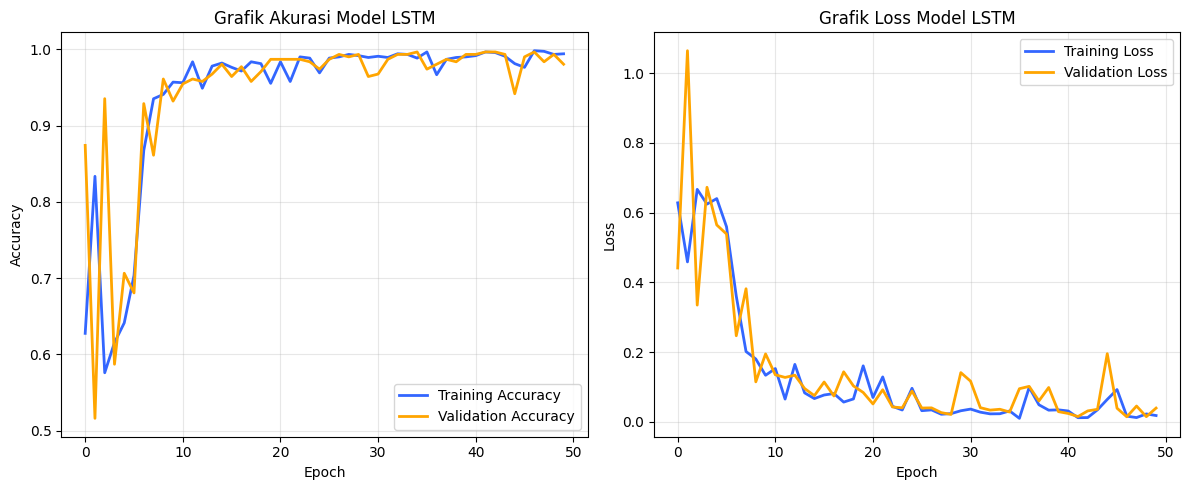


[SUCCESS] Pre-Trained Model biner berhasil dikunci dan disimpan secara lokal.


In [6]:
# Pembuatan plot grafik metriks evaluasi
plt.figure(figsize=(12, 5))

# Visualisasi grafik performa akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#3366FF', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FFA500', linewidth=2)
plt.title('Grafik Akurasi Model LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Visualisasi grafik performa loss function
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#3366FF', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#FFA500', linewidth=2)
plt.title('Grafik Loss Model LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Menyimpan arsitektur pre-trained model native Keras murni
model.save("model_lstm_binary_wifi_sensing.keras")
print("\n[SUCCESS] Pre-Trained Model biner berhasil dikunci dan disimpan secara lokal.")